<a href="https://colab.research.google.com/github/bajatsira/description-of-life-cycle-processes/blob/main/%D0%98%D0%A35%D0%A6_81%D0%91_%D0%A1%D0%B5%D0%BC%D0%B8%D0%BD%D0%B0%D1%803_%D0%A7%D1%83%D0%BF%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Использование методов фреймворка Scipy для проверки параметрических и непараметрических критериев

In [1]:
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt

В scipy.stats используются следующие функции:

Пусть $X$ — класс, реализующий некоторое распределение. Конкретное распределение с параметрами `params` можно получить как **`X(params)`**.
У него доступны следующие методы:

* `X(params).rvs(size=N)` — генерация выборки размера $N$ (<b>R</b>andom <b>V</b>ariate<b>S</b>). Возвращает `numpy.array`;
* `X(params).cdf(x)` — значение функции распределения в точке $x$ (<b>C</b>umulative <b>D</b>istribution <b>F</b>unction);
* `X(params).ppf(q)` — $q$-квантиль (<b>P</b>ercent <b>P</b>oint <b>F</b>unction);
* `X(params).mean()` — математическое ожидание;
* `X(params).median()` — медиана ($1/2$-квантиль);
* `X(params).var()` — дисперсия (<b>Var</b>iance);
* `X(params).std()` — стандартное отклонение = корень из дисперсии (<b>St</b>andard <b>D</b>eviation).
* `X(params).pdf(x)` — для непрерывных распределений значение плотности в точке $x$ (<b>P</b>robability <b>D</b>ensity <b>F</b>unction);
* `X(params).pmf(k)` — для дискретных распределений значение дискретной плотности в точке $k$ (<b>P</b>robability <b>M</b>ass <b>F</b>unction);

Эти методы применимы как к конкретному распределению `X(params)`, так и к самому классу `X`. Во втором случае параметры передаются в сам метод. Например, вызов `X.rvs(size=N, params)` эквивалентен `X(params).rvs(size=N)`. При работе с распределениями и случайными величинами рекомендуем использовать первый способ, посколько он больше согласуется с математическим синтаксисом теории вероятностей.

Параметры могут быть следующими:
* `loc` — параметр сдвига;
* `scale` — параметр масштаба;


# I. Параметрические тесты

Воспользуемся параметрическим критерием Стьюдента для проверки равенства средних.

Сгенерируем 3 выборки с разными параметрами нормального распределения - среднее=[1; 3; 1], дисперсия=[1; 1; 5] и размером=[50; 40; 60].

Для этого воспользуемся вероятностными функциями из  numpy

In [2]:
#
mean = [1, 2, 1]
variance = [1, 1, 4]
size = [50, 40, 60]

if len(mean) != len(variance) or len(variance) != len(size):
    print("Ошибка в исходных данных! Размер массивов должен совпадать!")
#
task_arr = []
for i in range(len(size)):
    task_arr.append(np.random.normal(loc=mean[i], scale=np.sqrt(variance[i]), size=size[i]))
#
full_arr = np.array([])
for arr in task_arr:
    for num in arr:
        full_arr = np.append(full_arr, num)

print("mean of full =", round(np.mean(full_arr),3))

mean of full = 1.401


 1) Рассчитаем t-критерий для средних значений двух независимых выборок - ttest_ind.

Если equal_var=True, то выполняется стандартный независимый тест с двумя выборками, который предполагает равные дисперсии совокупности.
Если equal_var=False, то выполнится выриант t-критерия Уэлча, который не предполагает равную дисперсию.

In [3]:
alpha = 0.05
# Вычисляем t-статистику и p-value
t_stat, p_value = sst.ttest_ind(task_arr[0], task_arr[1], equal_var=True)
print("t-test -equal variances")
if p_value < alpha:
   print("Отвергаем нулевую гипотезу, т.к. существует статистически значимое различие между выборками.")
else:
   print("Не отвергаем нулевую гипотезу - не существует статистически значимого различия между выборками.")

# Вычисляем t-статистику и p-value
t_stat, p_value = sst.ttest_ind(task_arr[0], task_arr[1], equal_var=False)
print("t-test -not equal variances")
if p_value < alpha:
   print("Отвергаем нулевую гипотезу - существует статистически значимое различие между выборками.")
else:
   print("Не отвергаем нулевую гипотезу - не существует статистически значимого различия между выборками.")

t-test -equal variances
Отвергаем нулевую гипотезу, т.к. существует статистически значимое различие между выборками.
t-test -not equal variances
Отвергаем нулевую гипотезу - существует статистически значимое различие между выборками.


Получите результаты сравнения двух других пар выборок - task_arr[0] и task_arr[2]; task_arr[1] и task_arr[2]

In [4]:
# Вычисляем t-статистику и p-value

2) Используем тест Бартлетта для проверки равенства дисперсий.

Критерий Бартлетта (Bartlett's test) — статистический критерий, позволяющий проверять равенство дисперсий нескольких (двух и более) выборок. Нулевая гипотеза предполагает, что рассматриваемые выборки получены из генеральных совокупностей, обладающих одинаковыми дисперсиями.

Критерий Бартлетта является параметрическим и основан на дополнительном предположении о нормальности выборок данных, поэтому перед применением критерия Бартлетта рекомендуется выполнить проверку нормальности.

Плюсы:
- объёмы выборок могут быть различными,
- критерий Бартлетта выявляет отклонения, как в наибольшую, так и в наименьшую стороны;

Минусы:
- сложность вычислений,
- объём каждой выборки должен быть больше трёх,
- критерий очень чувствителен к нарушению предположения о нормальности закона распределения исходных данных.


In [5]:
# Уровень значимости
alpha = 0.05
# Вычисляем степени свободы выборок
x = task_arr[0]
df1 = len(x) - 1
y = task_arr[1]
df2 = len(y) - 1

stat, p_value = sst.bartlett(x, y)
print(stat.round(3), p_value.round(3))

# Сравниваем p-value с уровнем значимости
if p_value < alpha:
   print("Отвергаем нулевую гипотезу - существует статистически значимое различие в дисперсиях.")
else:
   print("Не отвергаем нулевую гипотезу - не существует статистически значимого различия в дисперсиях.")

0.884 0.347
Не отвергаем нулевую гипотезу - не существует статистически значимого различия в дисперсиях.


Получите результаты сравнения двух других пар выборок - task_arr[0] и task_arr[2]; task_arr[1] и task_arr[2]

In [6]:
# Вычисляем статистику и p-value

3) В фреймворке scipy.stats для проверки нормальности распределения реализован критерий д'Агостино-Пирсона. [По изданию D’Agostino, R. B. (1971) “An omnibus test of normality for moderate and large sample size”.] Но, им рекомендуется пользоваться при объемах выборок, превышающих тысячу наблюдений.

In [7]:
print("критерий Агостино-Пирсона")
# Генеральная совокупность
arr1k = np.random.normal(0, 1, size=1000)
stat, pvalue = sst.normaltest(arr1k)
print(f"Проверка выборки arr1k = {stat.round(3)}, {pvalue.round(3)}")

# Применяем критерий Агостиньо-Пирсона для проверки нормальности распределения
statistic, p_value = sst.normaltest(full_arr)
print(f"Проверка выборки full_arr = {statistic.round(3)}, {p_value.round(3)}")

# Сравниваем p-value с уровнем значимости alpha
if p_value < alpha:
   print("Отвергаем нулевую гипотезу, генеральная совокупность full_arr не распределена нормально.")
else:
   print("Не отвергаем нулевую гипотезу, генеральная совокупность full_arr распределена нормально.")

критерий Агостино-Пирсона
Проверка выборки arr1k = 5.814, 0.055
Проверка выборки full_arr = 2.737, 0.255
Не отвергаем нулевую гипотезу, генеральная совокупность full_arr распределена нормально.


### II. Метод получения выборки аппроксимацией

Допустим, у нас нет хорошего простого аналитического распределения, и мы не можем использовать его для аппроксимации нашего распределения. Можно использовать аппроксимацию нашей выборки на базе равномерного распределения методом отбрасывания некоторых точек. Выполняется следующим образом:

1. Выберем равномерно распределенное 'x'.
2. Выберем равномерно распределенное `y` от `0` до максимальной вероятности в нашем распределении плотности.
3. Если $y > p(x)$ то вычеркнем такую точку.

Попробуем выполнить выборку из *ненормализованного* распределения $p(x) = \sin(x^2) + 1$ от $0 \rightarrow 4$

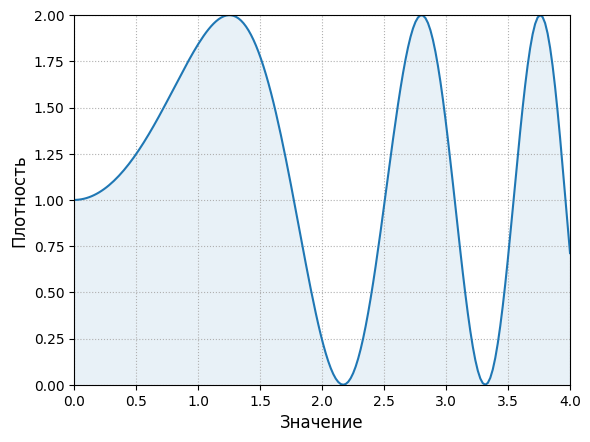

In [8]:
# сгенерировать выборку из распределения, которого нет в scipy.stats
def my_pdf(x):  return np.sin(x**2) + 1

# Рисуем график плотности непрерывного распределения
# функция linspace - Создание массива из равномерно распределенных значений,
# это последовательности чисел с постоянным шагом, или равномерная сетка в диапазоне значений
xs = np.linspace(0, 4, 200)
ps = my_pdf(xs)
plt.plot(xs, ps)
# закрасим область под графиком
plt.fill_between(xs, 0, ps, alpha=0.1)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':')
# ограничим оси
plt.xlim(0, 4); plt.ylim(0, 2);

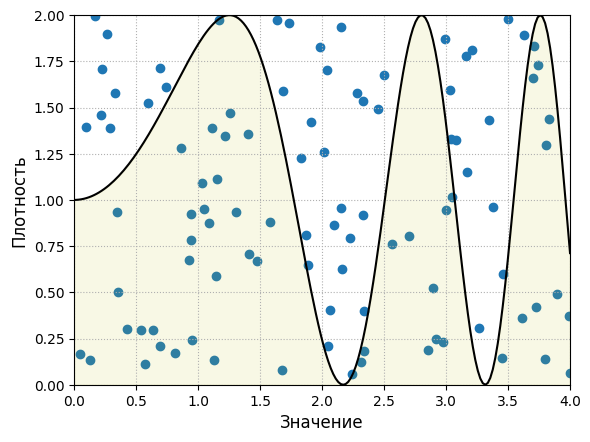

In [9]:
n = 100
# создадим поле равномерно распределенных значений
random_x = sst.uniform.rvs(loc=0, scale=4, size=n)
random_y = sst.uniform.rvs(loc=0, scale=2, size=n)

plt.scatter(random_x, random_y)
plt.plot(xs, ps, c="k")
# закрасим область под графиком
plt.fill_between(xs, 0, ps, color="y", alpha=0.1)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':')
# ограничим оси
plt.xlim(0, 4), plt.ylim(0, 2);

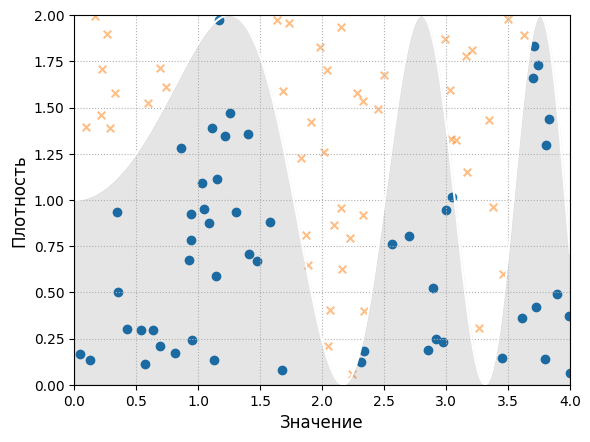

In [10]:
# отфильтруем точки по нашей функции
passed = random_y <= my_pdf(random_x)
# отобразим две группы точек
plt.scatter(random_x[passed], random_y[passed])
plt.scatter(random_x[~passed], random_y[~passed], marker="x", s=30, alpha=0.5)

plt.plot(xs, ps, c="w")
# закрасим область под графиком
plt.fill_between(xs, 0, ps, color="k", alpha=0.1)
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':')
# ограничим оси
plt.xlim(0, 4), plt.ylim(0, 2);

59221


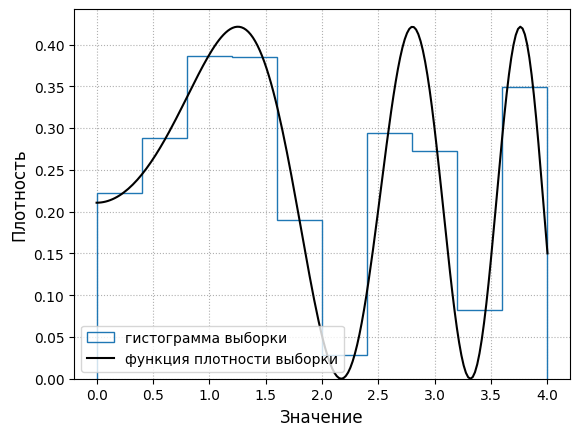

In [11]:
n2 = 100000
x_test = sst.uniform.rvs(scale=4, size=n2)
x_final = x_test[sst.uniform.rvs(scale=2, size=n2) <= my_pdf(x_test)]
print(len(x_final))

# используем метод интегрирования с помощью выборок вдоль заданной оси и правила Симпсона.
from scipy.integrate import simpson

plt.hist(x_final, density=True, histtype="step", label="гистограмма выборки")
plt.plot(xs, ps / simpson(ps, x=xs), c="k", label="функция плотности выборки")
plt.xlabel('Значение', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.grid(ls=':')
plt.legend(loc=3);

### III. Выборка методом обратного преобразования

Концептуально так: мы знаем, что для всех PDF значение CDF изменяется от 0 до 1.
Если можно равномерно отобрать CDF от 0 до 1, можем ли мы инвертировать нашу функцию, чтобы восстановить значение $x$, которое дает выборочное значение CDF ?

Для некоторых функций - это возможно, но для некоторых - нет, математика неразрешима!

Приведенная выше функция сложна, поэтому найдем функцию, которую проще использовать для сэмплирования.

Допустим, наш PDF равен $p(x) = 3 x ^ 2$ из $0 \rightarrow 1$. В отличие от предыдущей функции, эта нормализована.

Можно найти CDF с помощью

$$ CDF(x) = \int_0^x p(x ^\prime) dx ^\prime = x ^ 3 $$

Теперь есть CDF и мы хотим его инвертировать, то есть на данный момент у нас есть значение $x$ и получаем значение $y$ - CDF.
Мы хотим присвоить ему значение CDF и получить значение $x$:

$$ y = x^3 \rightarrow x = y^3 $$

здесь получится $y = x^{1/3}$ или в виде CDF $x = CDF^{1/3}$


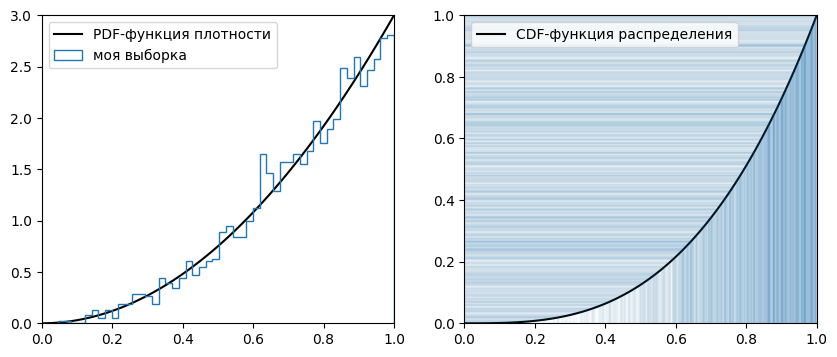

In [12]:
def pdf(x):  return 3 * x**2
def cdf(x):  return x**3
def icdf(cdf):  return cdf**(1/3)

# Создание массива из равномерно распределенных значений
xs = np.linspace(0, 1, 100)
pdfs = pdf(xs)
cdfs = cdf(xs)
n = 2000
u_samps = sst.uniform.rvs(size=n)
x_samps = icdf(u_samps)

# построим две диаграммы рядом PDF и CDF
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
axes[0].plot(xs, pdfs, color="k", label="PDF-функция плотности")
axes[0].hist(x_samps, density=True, histtype="step", label="моя выборка", bins=50)
axes[1].plot(xs, cdfs, color="k", label="CDF-функция распределения")

axes[1].hlines(u_samps, 0, x_samps, linewidth=0.1, alpha=0.3)
axes[1].vlines(x_samps, 0, u_samps, linewidth=0.1, alpha=0.3)

axes[0].legend(), axes[1].legend()
axes[0].set_xlim(0, 1), axes[0].set_ylim(0, 3)
axes[1].set_xlim(0, 1), axes[1].set_ylim(0, 1);

Проверим возможность применения метода обратного преобразования для получения своего распределения

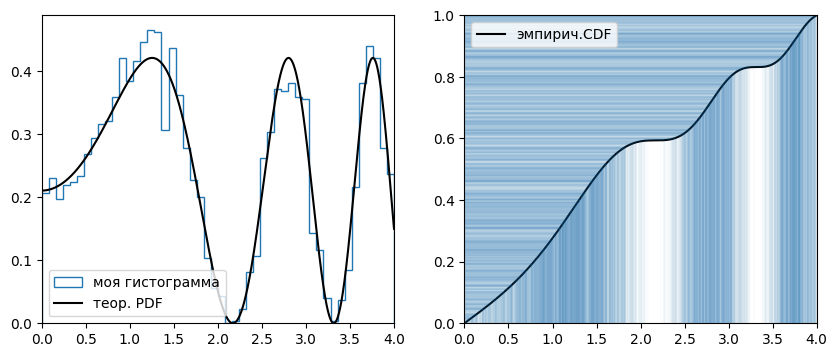

In [13]:
from scipy.interpolate import interp1d

def my_pdf(x):  return np.sin(x**2) + 1
# Создание массива из равномерно распределенных значений
xs = np.linspace(0, 4, 4000)
pdfs = my_pdf(xs)
cdfs = pdfs.cumsum() / pdfs.sum()  # опасное действие! результат не гарантирован!
# при получении ошибки повторно выполняйте код до получения результата!

# Создание выборки из равномерно распределенных значений
u_samps = sst.uniform.rvs(size=4000)
x_samps = interp1d(cdfs, xs, bounds_error=False, fill_value='extrapolate')(u_samps)

# построим две диаграммы рядом PDF и CDF
fig, axes = plt.subplots(ncols=2, figsize=(10,4))
axes[0].hist(x_samps, density=True, histtype="step", label="моя гистограмма", bins=50)
axes[0].plot(xs, pdfs/4.747, color="k", label="теор. PDF")
axes[0].legend(loc=3), axes[0].set_xlim(0, 4)

axes[1].plot(xs, cdfs, color="k", label="эмпирич.CDF")
axes[1].hlines(u_samps, 0, x_samps, linewidth=0.1, alpha=0.3)
axes[1].vlines(x_samps, 0, u_samps, linewidth=0.1, alpha=0.3)
axes[1].legend(loc=2), axes[1].set_xlim(0, 4), axes[1].set_ylim(0, 1);

## IV. Интерполяция данных

Нам нужен способ интерполяции между точками с некоторой точностью.
Кратко рассмотрим интерполяцию.

### Вариант вычисления эмпирических PDF, CDF и SF.

Предположим, что у нас есть несколько значений из некоторого распределения. Как можно получить непрерывную функцию для дальнейшего использования?

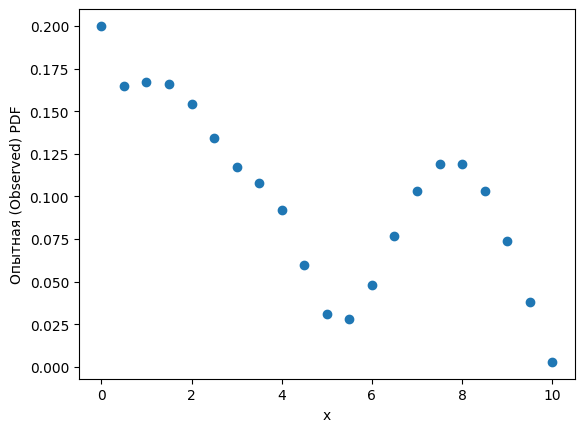

In [14]:
xs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
      5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
ys = [0.2, 0.165, 0.167, 0.166, 0.154, 0.134, 0.117,
      0.108, 0.092, 0.06, 0.031, 0.028, 0.048, 0.077,
      0.103, 0.119, 0.119, 0.103, 0.074, 0.038, 0.003]

plt.scatter(xs, ys)
plt.xlabel("x")
plt.ylabel("Опытная (Observed) PDF");

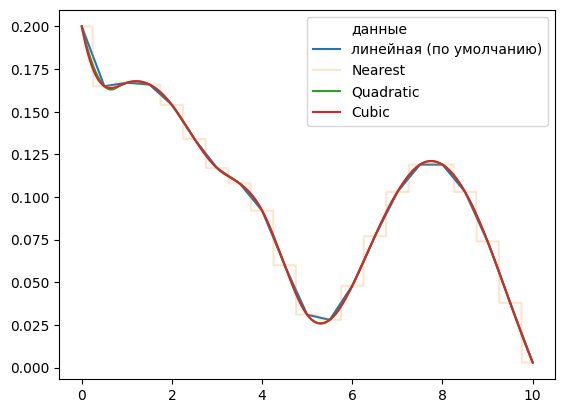

In [15]:
# используем интерполяцию из фреймворка scipy
from scipy.interpolate import interp1d

x = np.linspace(min(xs), max(xs), 1000)
y1 = interp1d(xs, ys)(x)
y2 = interp1d(xs, ys, kind="nearest")(x)
y3 = interp1d(xs, ys, kind="quadratic")(x)
y4 = interp1d(xs, ys, kind="cubic")(x)

plt.scatter(xs, ys, s=30, label="данные", c="w")
plt.plot(x, y1, label="линейная (по умолчанию)")
plt.plot(x, y2, label="Nearest", alpha=0.2)
plt.plot(x, y3, label="Quadratic", ls='-')
plt.plot(x, y4, label="Cubic", ls='-')
plt.legend();

Используя `interp1d` можно найти вероятность для любого значения `x`.

Как можно вычислить CDF и вероятность для значений между границами? - С помощью `scipy.integrate`!
Есть несколько методов вычисления интеграла:

* `scipy.integrate.trapz` для низкой точности, но высокой скорости вычисления
* `scipy.integrate.simpson` для средней точности, но достаточно высокой скорости вычисления
* `scipy.integrate.quad` для высокой точности, но низкой скорости вычисления


In [16]:
from scipy.integrate import simpson

def get_prob(xs, ys, a, b, resolution=1000):
    x_norm = np.linspace(min(xs), max(xs), resolution)
    y_norm = interp1d(xs, ys, kind="quadratic")(x_norm)
    normalisation = simpson(y_norm, x=x_norm)
    x_vals = np.linspace(a, b, resolution)
    y_vals = interp1d(xs, ys, kind="quadratic")(x_vals)
    return simpson(y_vals, x=x_vals) / normalisation

def get_cdf(xs, ys, v):
    return get_prob(xs, ys, min(xs), v)

# в интервале от 0 до 10
print(get_prob(xs, ys, 0, 10))

1.0


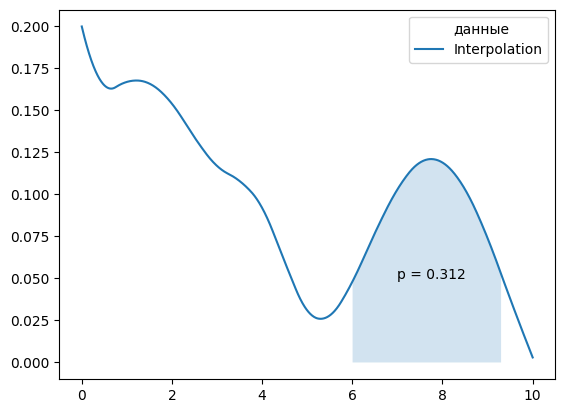

In [17]:
# в интервале от 6 до 9.3
v1, v2 = 6, 9.3
area = get_prob(xs, ys, v1, v2)

plt.scatter(xs, ys, s=30, label="данные", color="w")
plt.plot(x, y3, linestyle="-", label="Interpolation")
plt.fill_between(x, 0, y3, where=(x>=v1)&(x<=v2), alpha=0.2)
plt.annotate(f"p = {area:.3f}", (7, 0.05))
plt.legend();

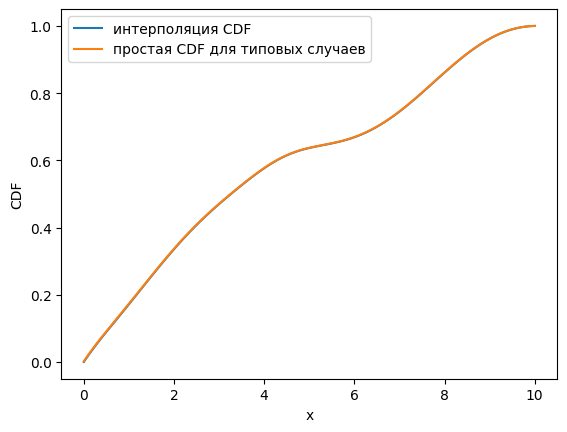

In [18]:
x_new = np.linspace(min(xs), max(xs), 100)
cdf_new = [get_cdf(xs, ys, i) for i in x_new]
cp_cdf = y3.cumsum() / y3.sum()

plt.plot(x_new, cdf_new, label="интерполяция CDF")
plt.plot(x, cp_cdf, label="простая CDF для типовых случаев")
plt.ylabel("CDF")
plt.xlabel("x")
plt.legend();

Обратите внимание, что метод CDF, который здесь реализован, является простым, но довольно медленным.

Обычно следует один раз определить функцию CDF с высокой точностью и сохранить результат, а затем можно просто интерполировать его. Пересчитывать его каждый раз - пустая трата процессорного времени.

Для подавляющего большинства приложений метод `cumsum()` подходит, если у вас есть массив с достаточным количеством точек.

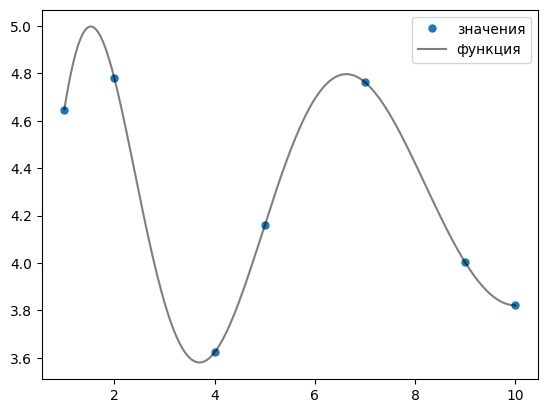

In [19]:
# пример - произвольная функция некоторого распределния
def fn(xs):
    return np.exp((xs + 10.5)**0.1) + np.sin(xs) / (xs + 1) + np.cos(2.5 * xs**0.5)**2

xs = np.array([1, 2, 4, 5, 7, 9, 10])
ys = fn(xs)
# Создание массива из равномерно распределенных значений
x_fine = np.linspace(1, 10, 200)
y_fine = fn(x_fine)

plt.plot(xs, ys, 'o', label="значения", markersize=5)
plt.plot(x_fine, y_fine, label="функция", color="k", alpha=0.5, linestyle="-")
plt.legend();

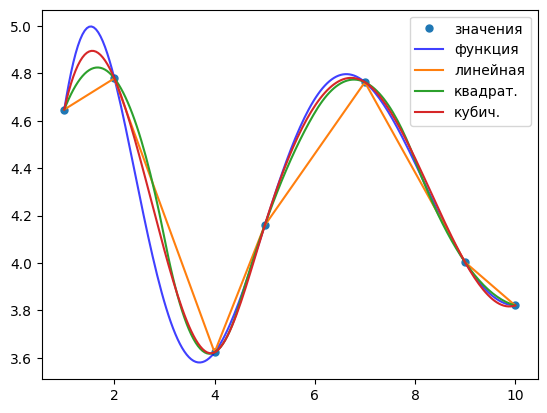

In [20]:
# линейная интерполяция
y_linear = interp1d(xs, ys, kind="linear")(x_fine)
# квадратичная интерполяция
y_quad = interp1d(xs, ys, kind="quadratic")(x_fine)
# кубическая интерполяция
y_cubic = interp1d(xs, ys, kind="cubic")(x_fine)

plt.plot(xs, ys, 'o', label="значения", markersize=5)
plt.plot(x_fine, y_fine, label="функция", color="b", ls="-", alpha=0.75)
plt.plot(x_fine, y_linear, label="линейная")
plt.plot(x_fine, y_quad, label="квадрат.")
plt.plot(x_fine, y_cubic, label="кубич.")
plt.legend();

In [21]:
class empiric_gen(sst.rv_continuous):
   def _pdf(self, x):
      return np.exp((x + 10.5)**0.1) + np.sin(x) / (x + 1) + np.cos(2.5 * x**0.5)**2

empir = empiric_gen(a=1, b=9, name='experiment')
sampl_emp = empir.rvs(size=200)

print('Первые 10 значений выборки:\n', sampl_emp[:10])
print(f'Выборочное среднее: {sampl_emp.mean():.3f}' )
print(f'Выборочная дисперсия: {sampl_emp.var():.3f}' )

Первые 10 значений выборки:
 [1.07932589 1.19069052 1.10819909 1.18662089 1.01150887 1.10623849
 1.00231379 1.13894305 1.03642184 1.14341249]
Выборочное среднее: 1.106
Выборочная дисперсия: 0.004


Если дискретная случайная величина может принимать небольшое число значений, то можно и не создавать новый класс, а явно указать эти значения и их вероятности (как в табличном формате Excel).

In [22]:
some_distribution = sst.rv_discrete(
    name='мое распределение',
    values=([1, 3, 7], [0.6, 0.1, 0.3])  # значения и вероятности
)
sample = some_distribution.rvs(size=200)

print('Первые 20 значений выборки:\n', sample[:20])
print(f'Выборочное среднее: {sample.mean():.3f}' )
print('Частота значений по выборке:', (sample == 1).mean(), (sample == 3).mean(), (sample == 7).mean())

Первые 20 значений выборки:
 [7 1 1 1 7 7 7 7 7 1 1 7 1 1 1 1 1 1 7 7]
Выборочное среднее: 3.170
Частота значений по выборке: 0.595 0.065 0.34


# V. Интервальная оценка выборочных данных

Смоделируем НЕнормальное распределение, чтобы проиллюстрировать центральную предельную теорему (ЦПТ).

ЦПТ утверждает, что распределение, которое получается из суммы многих выборок произвольного распределения, приближается к нормальному распределению, поскольку суммируется все больше и больше различных точек.

 Функция `my_get_data` реализует способ получения выборки произвольного распределения.

2000


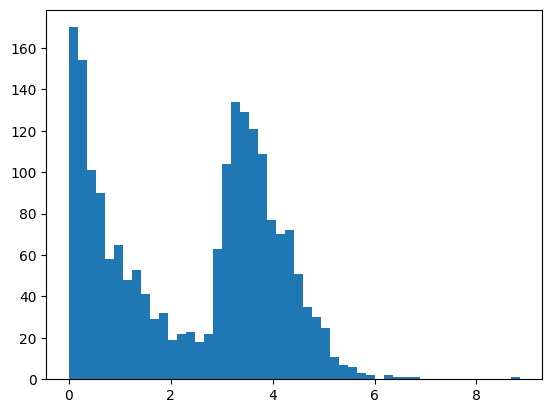

In [23]:
def my_get_data(n):
    # объединим данные из двух различных распределений
    data = np.concatenate(
             (sst.expon.rvs(scale=1, size=n//2),
              sst.skewnorm.rvs(5, loc=3, size=n//2)))
    # перемешаем значения в массиве
    np.random.shuffle(data)
    return data
n=2000
plt.hist(my_get_data(n), bins=50)
print(n)

Это определенно не нормальное распределение.

Обычно в практических экспериментах нет возможности запрашивать бесконечные объемы данных - приходится постепенно их собирать, что требует времени, усилий или денег.

Предположим, получено только 10 точек данных. Вычислим среднее значение этой выборки.

2.6994678403369443


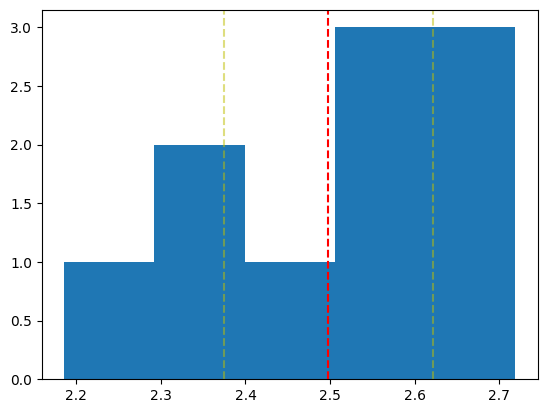

In [24]:
d10 = my_get_data(10)
print(d10.mean())
# построим гистограмму по 10 выборкам с 10 значениями
ave_means = [my_get_data(10).mean() for i in range(10)]
plt.hist(ave_means, bins=5)
# вычислим доверительный интервал
ti10=sst.t.interval(0.95, loc=np.mean(ave_means), df=len(ave_means)-1, scale=sst.sem(ave_means))
## нарисуем верт.линии по значению среднего и довер.интервал
plt.axvline(np.mean(ave_means), label="mean",c='r', ls="--")
plt.axvline(ti10[0], label="mean-",c='y', ls="--", alpha=0.5)
plt.axvline(ti10[1], label="mean+",c='y', ls="--", alpha=0.5);

Если повторить эту операцию несколько раз, то увидим, что ответ меняется после каждого выполнения кода!

Дело в том, что величина среднего выборочного не случайна. Между прогонами это так, но у этого результата есть определенные статистические свойства.

Давайте посмотрим, что произойдет, если нам удастся получить 10 точек данных 1000 раз. Проанализируем 1000 результатов mean()

0.2501154502779121


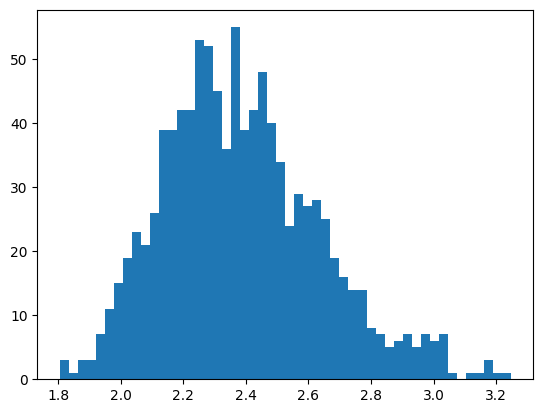

In [25]:
ave_means = [my_get_data(10).mean() for i in range(1000)]
plt.hist(ave_means, bins=50)
print(np.std(ave_means))

Распределение становится все больше и больше похожим на нормальное распределение. Пик распределения приближается к истинному среднему по совокупности, и ширина этого распределения является функцией как ширины совокупности, так и количества использованных нами выборок.

Если использовать 100 точек данных, можно ожидать меньшего разброса между выборками. Давайте протестируем это предположение.

0.08391726042495791


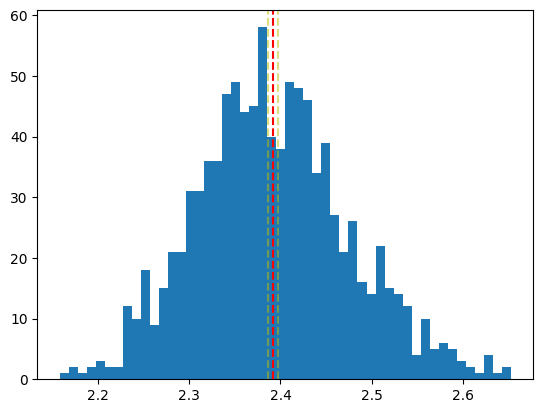

In [26]:
ave_means = [my_get_data(100).mean() for i in range(1000)]
plt.hist(ave_means, bins=50)
print(np.std(ave_means))
ti10=sst.t.interval(0.95, loc=np.mean(ave_means), df=len(ave_means)-1, scale=sst.sem(ave_means))
## нарисуем верт.линию по значению среднего
plt.axvline(np.mean(ave_means), label="mean",c='r', ls="--")
plt.axvline(ti10[0], label="mean-",c='y', ls="--", alpha=0.5)
plt.axvline(ti10[1], label="mean+",c='y', ls="--", alpha=0.5);

Это распределение выглядит более гауссовым! Можно заметить что и дисперсия здесь меньше, чем ранее.

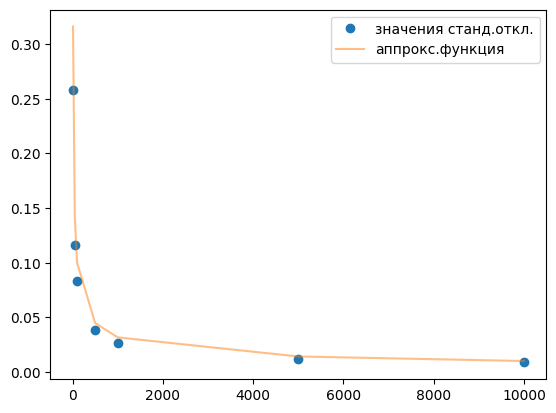

In [27]:
num_samps = [10, 50, 100, 500, 1000, 5000, 10000]
my_stda = []
# цикл получения новых данных
for n in num_samps:
    my_stda.append(np.std([my_get_data(n).mean() for i in range(1000)]))
# построение точечного графика с меткой "о"
plt.plot(num_samps, my_stda, 'o', label="значения станд.откл.")
# построение линейного графика аппроксимации зависимости std
plt.plot(num_samps, 1 / np.sqrt(num_samps), label="аппрокс.функция", alpha=0.5)
plt.legend();

Случайная функция не произвольна, она равна $1/\sqrt{N}$.

Распределение средних имеет стандартное отклонение, пропорциональное базовому распределению, деленному на квадр.корень из числа выборок.

Если у вас есть $N$ выборок, среднее значение выборок распределяется по нормальному распределению вокруг истинного среднего со стандартным отклонением $\sigma/\sqrt{N}$.

*Другое* следствие - если перейти от $N_1$ точек данных к $N_2$ точкам данных, можно определить среднее значение $\sqrt{N_2/N_1}$ более точно.
Увеличение количества данных в 4 раза не дает в 4 раза большей точности, но только удваивает точность.

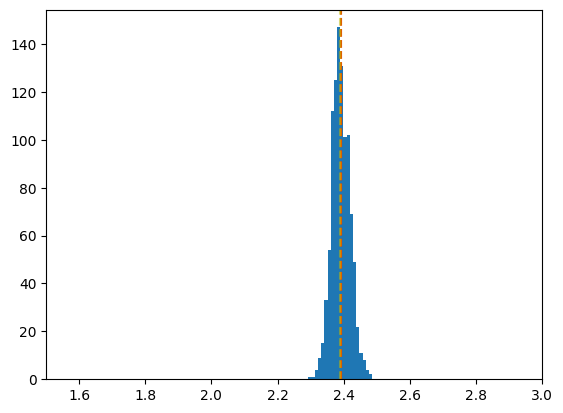

In [28]:
# получим гистограмму для 1000 значений
data0=[my_get_data(1000).mean() for i in range(1000)]
plt.hist(data0, bins=20)
# настроим ось Х в диапазон 1,5 -- 3,0
plt.xlim(1.5,3)
ti1000=sst.t.interval(0.95, loc=np.mean(data0), df=len(data0)-1, scale=sst.sem(data0))
## нарисуем верт.линию по значению среднего
plt.axvline(np.mean(data0), label="mean",c='r', ls="--")
plt.axvline(ti1000[0], label="mean-",c='y', ls="--", alpha=0.5)
plt.axvline(ti1000[1], label="mean+",c='y', ls="--", alpha=0.5);

1. Распределение выборочных средних приближается к нормальному
2. Ширина (дисперсия) определяется количеством точек, используемых для вычисления каждого выборочного среднего

Среднее значение совокупности =2.400 +/- 0.052


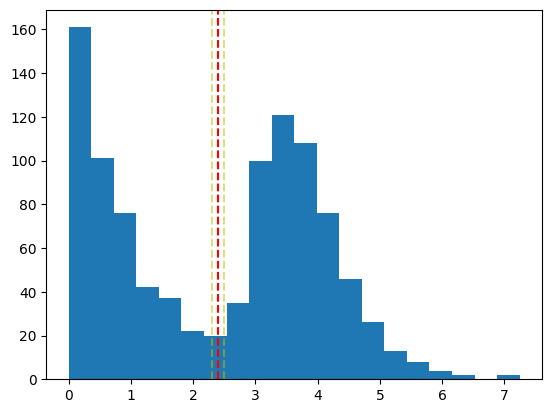

In [29]:
n = 1000
data1 = my_get_data(n)
sample_mean = np.mean(data1)
uncert_mean = np.std(data1) / np.sqrt(n)
plt.hist(data1, bins=20)
# получим 95%-доверительный интервал для среднего
ti3=sst.t.interval(0.95, loc=np.mean(data1), df=len(data1)-1, scale=sst.sem(data1))

## нарисуем верт.линии по значению среднего и доверит.интервала
plt.axvline(np.mean(data1), label="mean",c='r', ls="--")
plt.axvline(ti3[0], label="mean-",c='y', ls="--", alpha=0.5)
plt.axvline(ti3[1], label="mean+",c='y', ls="--", alpha=0.5)
print(f"Среднее значение совокупности ={sample_mean:.3f} +/- {uncert_mean:.3f}")

Наличие знака $\pm$ отражает неопределенность по нормальному распределению.

# VI. Непараметрические критерии
**Что делать, если аналитическое распределение не известно?**

Рассмотрим пример теста Колмогорова-Смирнова. Обратите внимание, что он предназначен для *непрерывных* распределений, мы используем его для дискретных для того, чтобы понимать пример, но надо следить за состоянием данных, чтобы быть уверенными в результатах, поэтому рассмотрим достаточно "непрерывное" дискретное распределение из файла 'loaded__100.txt'.

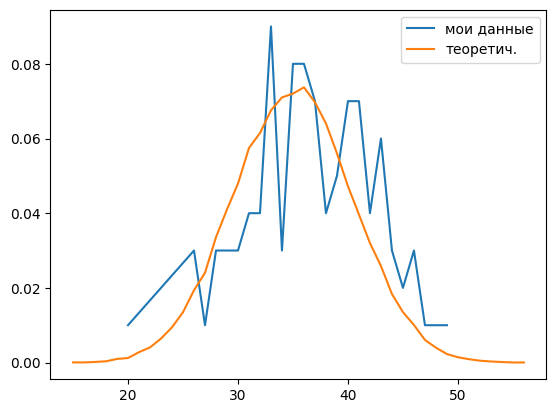

In [31]:
r_obs = np.array([36, 35, 30, 36, 31, 42, 27, 40, 42, 42, 46, 33, 33, 32, 28, 36, 37, 38, 33, 41, 33, 37, 34, 40, 49, 40, 26, 37, 43, 37, 46, 29, 36, 40, 44, 47, 38, 32, 28, 38, 45, 46, 30, 42, 44, 26, 33, 35, 36, 39, 43, 43, 43, 35, 29, 45, 35, 32, 43, 35, 33, 39, 34, 33, 41, 41, 35, 31, 44, 37, 41, 43, 35, 40, 38, 31, 29, 40, 37, 37, 28, 32, 36, 39, 33, 41, 39, 41, 41, 20, 35, 34, 39, 36, 26, 40, 36, 31, 33, 30])
# np.unique - найдем уникальные значения в массиве
# возвращает отсортированные элементы массива
# Если return_counts =True, также вернет массив счетчиков для каждого элемента, т.е частоты.

unique1, count_obs = np.unique(r_obs, return_counts=True)
count_obs = count_obs / count_obs.sum()  # нормализация

# для сравнения получим массив равномерно распределенных целых чисел
r_fair = np.random.randint(low=1, high=7, size=(50000, 10)).sum(axis=1)

# определим набор уникальных значений и их частоту встречаемости
unique2, count_fair = np.unique(r_fair, return_counts=True)
count_fair = count_fair / count_fair.sum()  # нормализация

plt.plot(unique1, count_obs, label="мои данные")
plt.plot(unique2, count_fair, label="теоретич.")
plt.legend(loc=1);

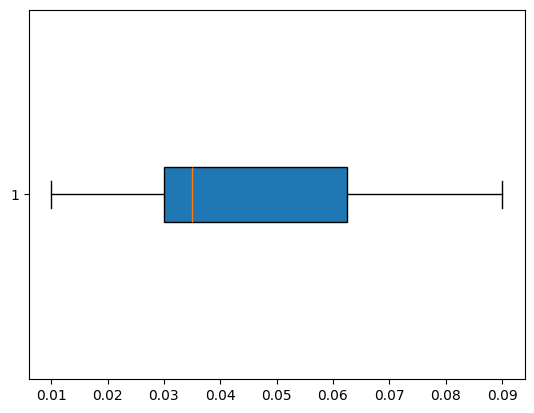

In [32]:
# удобно построить вид распределения в коробчатой диаграмме (ящик-с-усами)
plt.boxplot(count_obs, vert=False, patch_artist=True)
print()

Набор данных выглядит довольно вариативно.
Если сравнивать по PDF (диаграмме плотности), то приходится объединять результаты в подинтервалы, и трудно получить хорошую диаграмму, если нет большого количества данных.
В таком случае можно построить график распределения (CDF), для которого не нужно формировать данные в гистограмму.

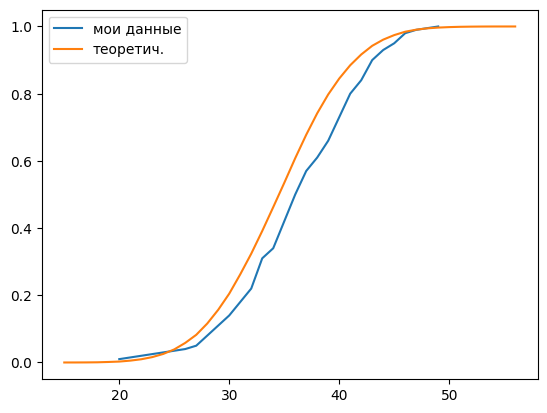

In [33]:
cdf_obs = count_obs.cumsum()
cdf_fair = count_fair.cumsum()
'''
cumsum() — функция в NumPy, которая вычисляет кумулятивные суммы элементов массива по всему массиву или по заданной оси, если указана ось.
Синтаксис функции: numpy.cumsum(array, axis=None, dtype=None, out=None)
Аргументы функции: array — входной массив; axis — ось, по которой вычисляется кумулятивная сумма, если не указано, массив сглаживается.
sa = np.array([[100, 200, 150, 220], [300, 200, 150, 100]])
cumsum = np.cumsum(sa)
# cumsum => ([ 100, 300, 450, 670, 970, 1170, 1320, 1420])
'''
plt.plot(unique1, cdf_obs, label="мои данные")
plt.plot(unique2, cdf_fair, label="теоретич.")
plt.legend(loc=2);

## Критерий согласия Колмогорова-Смирнова

*Вызов: kstest (rvs, cdf, args=())*

где

  rvs  --- выборка

  cdf  --- функция распределения (сама функция или ее название)

  args  --- параметры распределения

Воспользуемся тестом Колмогорова-Смирнова из scipy.stats для двух выборок.

Для двух выборок KS-статистика =0.138, p-value =0.041


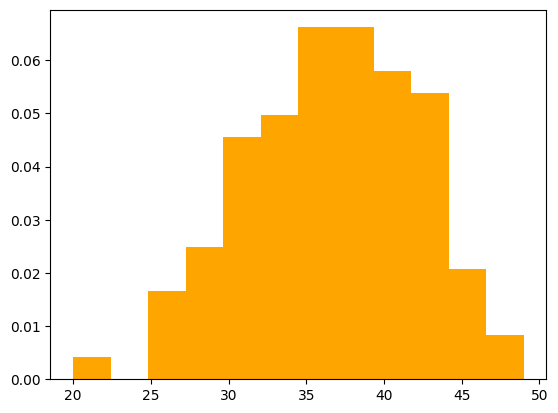

In [34]:
# отобразим вид наших данных
plt.hist(r_obs, bins=12, density=True, label='histo', color='orange')
# проверка распределений двух выборок
statistic, pvalue = sst.ks_2samp(r_obs, r_fair)
print(f"Для двух выборок KS-статистика ={statistic:.3f}, p-value ={pvalue:.3f}")

In [35]:
# проверка распределений выборки и равномерного распределения
stats, pval = sst.kstest(r_obs, cdf=sst.uniform.cdf)
print(f"Для равномерного распределения KS-статистика ={stats:.3f}, p-value ={pval:.3f}")

# проверка распределений выборки и нормального распределения
print(sst.kstest(r_obs, sst.norm.cdf))

Для равномерного распределения KS-статистика =1.000, p-value =0.000
KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.int64(20), statistic_sign=np.int8(-1))


Подготовим удобную функцию для использования теста Колмогорова-Смирнова для проверки нормальности с визуализацией гистограммы

KstestResult(statistic=np.float64(0.06273545565200633), pvalue=np.float64(0.8026465302276583), statistic_location=np.float64(0.04328931165052594), statistic_sign=np.int8(1))


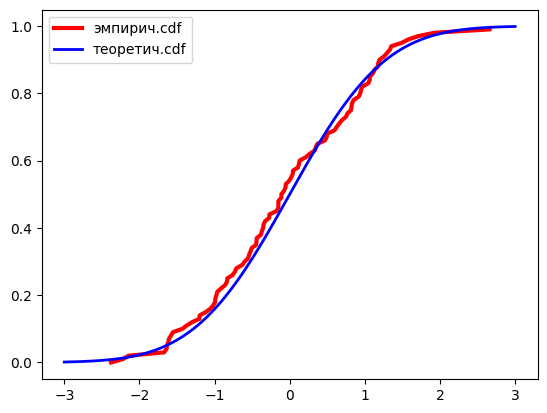

In [36]:
def apply_kstest(sample, cdf=sst.norm.cdf):
    print(sst.kstest(sample, cdf=cdf))
    # ECDF(sample) -- эмпирическая CDF
    xx = np.sort(sample)
    yy = np.arange(len(xx))/float(len(xx))
    grid = np.linspace(-3, 3, 500)

    #plt.figure(figsize=(8, 3.5))
    plt.plot(xx, yy, c='red', label='эмпирич.cdf', lw=3)
    plt.plot(grid, cdf(grid), c='blue', label='теоретич.cdf', lw=2)
    plt.legend()

apply_kstest(sst.norm.rvs(size=100));

Обратите внимание - Критерий не чувствителен к хвостам распределений. Например, проверим распределение Коши

KstestResult(statistic=np.float64(0.1721586142857527), pvalue=np.float64(0.004623707532462048), statistic_location=np.float64(-1.573155694533155), statistic_sign=np.int8(1))


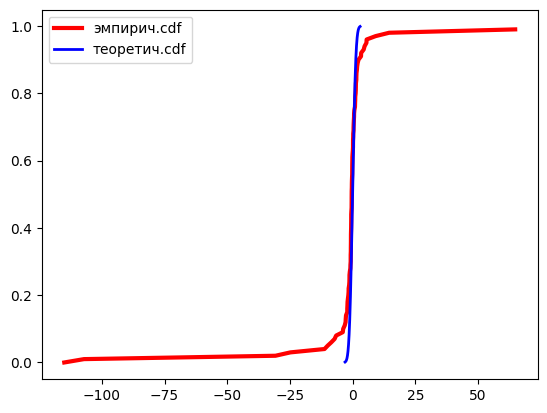

In [37]:
apply_kstest(sst.cauchy.rvs(size=100))

**Тест Пирсона $\chi^2$**

Критерий согласия Пирсона (хи-квадрат)

𝖧0 : Выборка из некоторого класса распределений

𝖧1 : 𝖧0 не верна
$$ \chi^2 = \sum_{i=1}^{n} \frac{(C_i - E_i)^2}{E_i} $$

Что значит статистика $\chi^2$ ? Можно сконвертировать результат в вероятность  по $\chi^2$ распределению

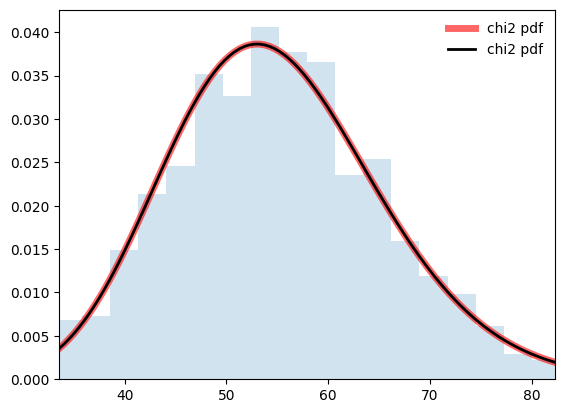

In [38]:
# chi2 - Непрерывная случайная величина хи-квадрат
df = 55 # примем количество степеней свободы =55
# Вычислим первые четыре момента выборки
mean, var, skew, kurt = sst.chi2.stats(df, moments='mvsk')

x = np.linspace(sst.chi2.ppf(0.01, df),
                sst.chi2.ppf(0.99, df),
                100)
# Отобразим функцию плотности вероятности (pdf -Probability Density Function)
# pdf(x) — значение плотности в точке x
plt.plot(x, sst.chi2.pdf(x, df), 'r-', lw=5, alpha=0.6, label='chi2 pdf')
rv = sst.chi2(df)

# Проверим точность cdf и ppf
plt.plot(x, rv.pdf(x), 'k-', lw=2, label='chi2 pdf')
vals = sst.chi2.ppf([0.001, 0.5, 0.999], df)
np.allclose([0.001, 0.5, 0.999], sst.chi2.cdf(vals, df))

# Генерация случайных чисел
r = sst.chi2.rvs(df, size=1000)

# сравним гистограмму
plt.hist(r, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
plt.xlim([x[0], x[-1]])
plt.legend(loc='best', frameon=False);

Значение p-value = 0.221


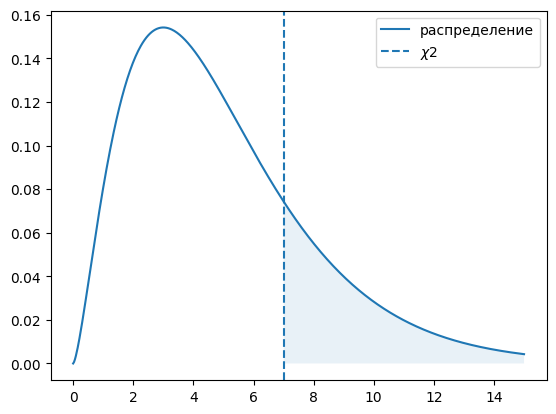

In [39]:
## используем функцию chi2 из фреймворка scipy.stats
chi2s = np.linspace(0, 15, 500)
prob = sst.chi2.pdf(chi2s, 5)

chi2_val = 7 # число выбрано просто для примера!
## нарисуем график распределения
plt.plot(chi2s, prob, label="распределение")
## нарисуем верт.линию по значению статистики
plt.axvline(chi2_val, label="$\\chi2$", ls="--")
## заштрихуем критич.область
plt.fill_between(chi2s, prob, 0, where=(chi2s>=chi2_val), alpha=0.1)
## выведем на диаграмму легенду
plt.legend()
# sf - Функция выживания, она определяется как (1 - cdf) // Survival function
## выведем на консоль
print(f"Значение p-value = {sst.chi2.sf(chi2_val, 5):.3f}")

*Вызов: chisquare (f_obs, f_exp=None, ddof=0)*

где

  f_obs  --- число элементов выборки, попавших в каждый из интервалов

  f_exp  --- ожидаемое число (по умолчанию равномерное)

  ddof  --- поправка на число степеней свободы. Статистика асимптотически будет иметь распределение 𝑘 − 1 − 𝑑𝑑𝑜𝑓, где 𝑘 -- число интервалов.

Несколько тестов могут быть использованы. При поиске нужного способа проверки гипотезы, это называется "поиск значимости", помните: чем конкретнее ваш "вопрос", тем более мощный тест нужно использовать.

В этом примере используется одностороннее распределение, которое проверяет предположение - не является ли наше наблюдаемое распределение *слишком отличным* от теоретического.

Если использовать двустороннее распределение, то предположение будет другим - не является ли наше наблюдаемое распределение *слишком похожим* на базовое.

Для проверки своих данных выгрузите из модели Excel семинара столбец W в формате txt (здесь как файл - 12345.prn)

прочитано 50 строк |среднее значение = 0.004 |стандарт.отклонение = 0.003 |максим.значение = 0.009
DescribeResult(nobs=np.int64(50), minmax=(np.float64(0.00069444444), np.float64(0.00902777778)), mean=np.float64(0.004013888886200001), variance=np.float64(6.481678320212271e-06), skewness=np.float64(0.42599376359289665), kurtosis=np.float64(-1.264159063923972))


ValueError: weights should have the same shape as x

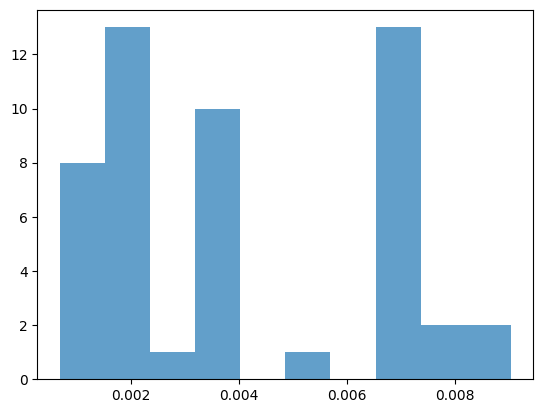

In [45]:
from collections import Counter
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt

# Заменяет загрузку: s_obs = np.loadtxt("12345.prn", dtype="str")
s_obs = np.array([
    "0,00347222222", "0,00069444444", "0,00347222222", "0,00208333333", "0,00208333333",
    "0,00069444444", "0,00694444444", "0,00694444444", "0,00694444444", "0,00208333333",
    "0,00347222222", "0,00347222222", "0,00694444444", "0,00208333333", "0,00694444444",
    "0,00138888889", "0,00277777778", "0,00763888889", "0,00763888889", "0,00902777778",
    "0,00208333333", "0,00208333333", "0,00208333333", "0,00486111111", "0,00138888889",
    "0,00347222222", "0,00069444444", "0,00069444444", "0,00347222222", "0,00347222222",
    "0,00069444444", "0,00694444444", "0,00208333333", "0,00208333333", "0,00694444444",
    "0,00208333333", "0,00694444444", "0,00347222222", "0,00347222222", "0,00138888889",
    "0,00694444444", "0,00208333333", "0,00694444444", "0,00694444444", "0,00694444444",
    "0,00347222222", "0,00902777778", "0,00208333333", "0,00208333333", "0,00694444444"
])

# Преобразуем строки в массив вещественных чисел (float)
s_ob = np.array([float(so.replace(',', '.')) for so in s_obs_str])

# выведем полученный результат с основными параметрами
print(f"прочитано {len(s_obs_str)} строк |среднее значение = {s_ob.mean():.3f} |стандарт.отклонение = {s_ob.std():.3f} |максим.значение = {s_ob.max():.3f}")

desc_ob = sst.describe(s_ob, axis=0, ddof=1, bias=True, nan_policy='propagate')
print(desc_ob)

# stats(df, loc=0, scale=1, moments=’mv’)
# Mean(‘m’), variance(‘v’), skew(‘s’), kurtosis(‘k’)

# Calculate observed frequencies
s_hist = np.histogram(s_ob, bins=10)
f_obs_counts = s_hist[0]
bin_edges = s_hist[1]

# Calculate expected frequencies for a normal distribution
mu, sigma = s_ob.mean(), s_ob.std()
norm_dist = sst.norm(loc=mu, scale=sigma)

f_exp_counts = []
for i in range(len(bin_edges) - 1):
    prob_in_bin = norm_dist.cdf(bin_edges[i+1]) - norm_dist.cdf(bin_edges[i])
    f_exp_counts.append(prob_in_bin * len(s_ob))

f_exp_counts = np.array(f_exp_counts)

# Plotting
plt.hist(s_ob, bins=bin_edges, label='Observed', alpha=0.7)
plt.hist(s_ob, bins=bin_edges, weights=f_exp_counts, label='Expected (Normal)', alpha=0.7, histtype='step', edgecolor='black')
plt.legend()
plt.title('Observed vs Expected Frequencies')
plt.show()

# Perform chi-square test
chisq1, pv1 = sst.chisquare(f_obs_counts, f_exp_counts)
print(f"Значение статистики chi2 = {chisq1:.3f} и значение p-value = {pv1:.3f}")
if pv1 < 0.05:
    print("-Гипотезу H0 можно отклонить")
else:
    print("-Гипотезу H0 не отклоняем")

Примените тест Колмогорова к своим данным (возможно, перемасштабированным для лучшей визуализации, например, *100 )

In [47]:
# =====================================================================
# Применение критерия Колмогорова-Смирнова (на примере массива s_ob * 100)
# =====================================================================

# 1. Подготовка перемасштабированных данных
data_scaled = s_ob * 100  # Переводим данные в проценты (умножением на 100)

# 2. Оценка параметров для теоретического нормального распределения
# Чтобы проверить на соответствие нормальному закону, нужно передать его параметры (loc и scale)
mean_est = np.mean(data_scaled)
std_est = np.std(data_scaled, ddof=1) # несмещенное стандартное отклонение

# 3. Вызов теста Колмогорова-Смирнова
# 'norm' указывает на нормальное распределение, а args передает (mu, sigma)
ks_stat, p_value = sst.kstest(data_scaled, 'norm', args=(mean_est, std_est))

# 4. Вывод результатов работы критерия
print("Результаты теста Колмогорова-Смирнова:")
print(f"Статистика критерия (D): {ks_stat:.5f}")
print(f"p-value: {p_value:.5f}")
print("-" * 40)

# 5. Интерпретация результатов (уровень значимости alpha = 0.05)
alpha = 0.05
if p_value > alpha:
    print(f"Вывод: Так как p-value ({p_value:.5f}) > alpha ({alpha}), ")
    print("НЕТ оснований отвергнуть нулевую гипотезу (H0). ")
    print("Данные хорошо согласуются с нормальным законом распределения.")
else:
    print(f"Вывод: Так как p-value ({p_value:.5f}) <= alpha ({alpha}), ")
    print("Нулевая гипотеза (H0) ОТВЕРГАЕТСЯ в пользу альтернативной (H1).")
    print("Распределение данных статистически значимо отличается от нормального.")

Результаты теста Колмогорова-Смирнова:
Статистика критерия (D): 0.22424
p-value: 0.01087
----------------------------------------
Вывод: Так как p-value (0.01087) <= alpha (0.05), 
Нулевая гипотеза (H0) ОТВЕРГАЕТСЯ в пользу альтернативной (H1).
Распределение данных статистически значимо отличается от нормального.


__График QQ__

У вероятностного графика в математической статистике данные выводят на график относительно теоретического распределения таким образом, чтобы точки образовывали примерно прямую линию. Отклонения от этой прямой указывают на отклонения от заданного распределения.

График QQ («Q» обозначает квантиль ) — вероятностный график, представляющий собой графический метод сравнения двух распределений вероятностей путем расставления их квантилей друг против друга. Для этого надо задать набор интервалов для квантилей. Точке (х, у) на графике соответствует один из квантилей второго распределения (у-координата), построенная вместе с аналогичным квантилем первого распределения (х-координата). Таким образом, линия является параметрической кривой с параметром, равным количеству интервалов квантилей.

Если два сравниваемых распределения схожи, точки в графике QQ будут примерно лежать на прямой у = х. Если распределения линейно связаны, точки в графике QQ будут примерно лежать на одной прямой, но не обязательно на прямой у = х. График QQ также может быть использован в качестве графического средства оценки параметров в масштабе семейства распределений.

График QQ используется для сравнения формы распределения, обеспечивая графическое представление о свойствах, таких как местоположение, масштаб и асимметрия в двух распределениях. График QQ может быть использован для сравнения с набором данных или с теоретическим распределением. Использование графика QQ для сравнения двух наборов данных можно рассматривать как непараметрический подход к сравнению их распределений.

График QQ — более мощный подход, чем метод сравнения гистограмм двух образцов, но требует больше умений для интерпретации. График QQ, как правило, используется для сравнения данных с теоретической моделью.

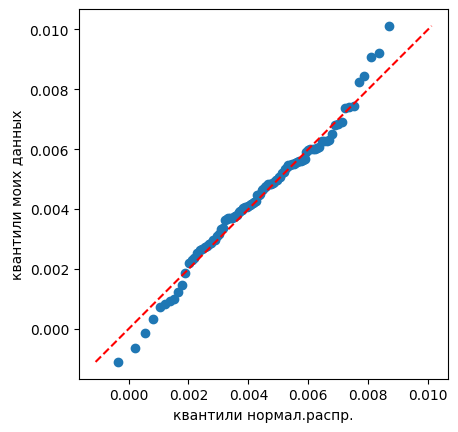

In [50]:
def QQ_plot(data):
    # сортировка по возрастанию
    yo = np.sort(data)

    # получить среднее и станд.отклонение
    mean, std = np.mean(yo), np.std(yo)

    # получить множество квантилей нормал.распределения
    # ppf(q) — q-й квантиль (Percent Point Function) - Inverse CDF
    ppf = sst.norm(loc=mean, scale=std).ppf
    xo = [ppf( i/(len(yo)+2) ) for i in range(1,len(yo)+1)]

    # построить точечный график Q-Q
    plt.scatter(xo, yo)

    # построить диагональную линию
    diag = np.linspace(np.min([xo,yo]), np.max([xo,yo]), 1000)
    plt.plot(diag, diag, c='red', linestyle='--')

    # график Q-Q в квадратной форме
    plt.gca().set_aspect('equal')

    # добавить подписи данных
    plt.xlabel('квантили нормал.распр.')
    plt.ylabel('квантили моих данных')

# сделаем для теста произвольные нормальные данные - через numpy или scipy
nx = np.random.normal(loc=0.004, scale=0.002, size=100)
#nx = sst.norm(loc=0.004, scale=0.002).rvs(size=100)
QQ_plot(nx)

Постройте QQ-график для своих данных.

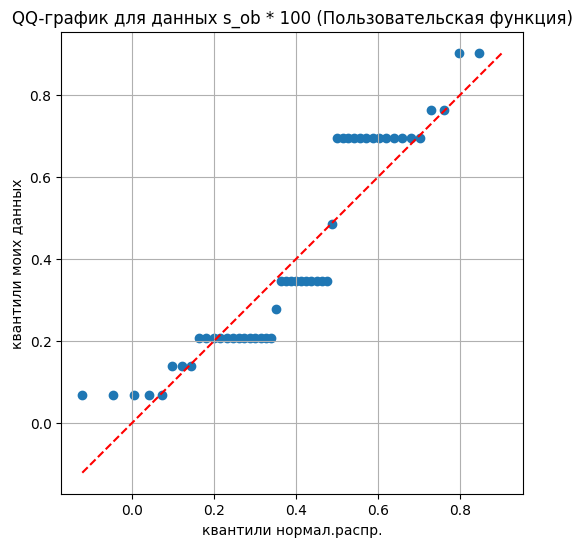

In [51]:

# 1. Подготовка перемасштабированных данных
data_scaled = s_ob * 100

# 2. Вызов функции построения графика, которая определена в вашем ноутбуке
plt.figure(figsize=(6, 6))
QQ_plot(data_scaled)  # Функция автоматически отсортирует данные и посчитает квантили

# 3. Настройка внешнего вида
plt.title("QQ-график для данных s_ob * 100 (Пользовательская функция)")
plt.grid(True)
plt.show()